<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/04.quantum-kernel-classification/01.iris-qsvm/19_qsvm_roc_auc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day27 QSVM ROC·AUC 실습

- Source: Google Drive `Day27/2-9.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Library Import


Library Import Completed

STEP 2. Load Prediction Score
Samples : 30

STEP 3. ROC Curve
ROC Curve Created
Number of Threshold : 16

STEP 4. AUC
AUC : 0.9689

STEP 5. Threshold Table
   Threshold  FPR       TPR
0        inf  0.0  0.000000
1   1.245357  0.0  0.066667
2   1.117756  0.0  0.333333
3   1.114206  0.0  0.533333
4   1.000018  0.0  0.800000

STEP 6. Save CSV
output/roc_curve.csv

STEP 7. Save Pickle
output/roc_info.pkl

STEP 8. ROC Plot


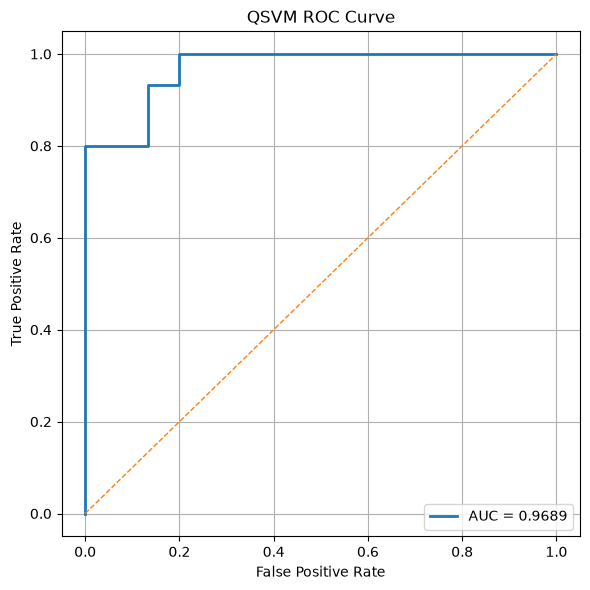

output/roc_curve.png

STEP 9. AUC Interpretation
AUC : 0.9689
Performance : Excellent

ROC Curve는
Threshold가 변하여도
모델이 얼마나 안정적인지를 보여줍니다.

AUC가 클수록
좋은 분류 모델입니다.

ROC & AUC SUMMARY
AUC : 0.9689
ROC Points : 16
Performance : Excellent
ROC Analysis Completed
Next Step : 2-10.py


In [1]:
"""
============================================================
Lab 15. QSVM Performance Evaluation


ROC Curve 및 AUC 계산
------------------------------------------------------------
이번 실습에서는

1. Prediction Score 불러오기
2. ROC Curve 계산
3. AUC 계산
4. Threshold 분석
5. ROC Curve 시각화
6. CSV 저장
7. 결과 해석

============================================================
"""

# ============================================================
# STEP 1. Library Import
# ============================================================

print("=" * 70)
print("STEP 1. Library Import")
print("=" * 70)

import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

print("Library Import Completed")

# ============================================================
# STEP 2. Load Prediction Score
# ============================================================

print("\n" + "=" * 70)
print("STEP 2. Load Prediction Score")
print("=" * 70)

y_test = np.load("output/y_test.npy")

y_score = np.load("output/y_score.npy")

print("Samples :", len(y_test))

# ============================================================
# STEP 3. ROC Curve
# ============================================================

print("\n" + "=" * 70)
print("STEP 3. ROC Curve")
print("=" * 70)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_score
)

print("ROC Curve Created")

print("Number of Threshold :", len(thresholds))

# ============================================================
# STEP 4. AUC
# ============================================================

print("\n" + "=" * 70)
print("STEP 4. AUC")
print("=" * 70)

auc = roc_auc_score(
    y_test,
    y_score
)

print(f"AUC : {auc:.4f}")

# ============================================================
# STEP 5. Threshold DataFrame
# ============================================================

print("\n" + "=" * 70)
print("STEP 5. Threshold Table")
print("=" * 70)

roc_df = pd.DataFrame({

    "Threshold": thresholds,

    "FPR": fpr,

    "TPR": tpr

})

print(roc_df.head())

# ============================================================
# STEP 6. Save CSV
# ============================================================

print("\n" + "=" * 70)
print("STEP 6. Save CSV")
print("=" * 70)

roc_df.to_csv(
    "output/roc_curve.csv",
    index=False
)

print("output/roc_curve.csv")

# ============================================================
# STEP 7. Save Pickle
# ============================================================

print("\n" + "=" * 70)
print("STEP 7. Save Pickle")
print("=" * 70)

roc_info = {

    "auc": auc,

    "fpr": fpr,

    "tpr": tpr,

    "threshold": thresholds

}

with open(
    "output/roc_info.pkl",
    "wb"
) as f:

    pickle.dump(
        roc_info,
        f
    )

print("output/roc_info.pkl")

# ============================================================
# STEP 8. ROC Curve Plot
# ============================================================

print("\n" + "=" * 70)
print("STEP 8. ROC Plot")
print("=" * 70)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("QSVM ROC Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "output/roc_curve.png",
    dpi=200
)

plt.show()

print("output/roc_curve.png")

# ============================================================
# STEP 9. AUC Interpretation
# ============================================================

print("\n" + "=" * 70)
print("STEP 9. AUC Interpretation")
print("=" * 70)

print(f"AUC : {auc:.4f}")

if auc >= 0.95:

    level = "Excellent"

elif auc >= 0.90:

    level = "Very Good"

elif auc >= 0.80:

    level = "Good"

elif auc >= 0.70:

    level = "Fair"

else:

    level = "Poor"

print("Performance :", level)

print()

print("ROC Curve는")

print("Threshold가 변하여도")

print("모델이 얼마나 안정적인지를 보여줍니다.")

print()

print("AUC가 클수록")

print("좋은 분류 모델입니다.")

# ============================================================
# STEP 10. Summary
# ============================================================

print("\n" + "=" * 70)
print("ROC & AUC SUMMARY")
print("=" * 70)

print(f"AUC : {auc:.4f}")

print(f"ROC Points : {len(fpr)}")

print(f"Performance : {level}")

print("=" * 70)

print("ROC Analysis Completed")

print("Next Step : 2-10.py")

print("=" * 70)